In [3]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib 
import os

sns.set_style("whitegrid")
%matplotlib inline
print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Shape (Rows, Columns):", df.shape)
print("\nTarget Classes:", data.target_names)
print("\nClass Distribution (Balanced dataset):")
print(df['target'].value_counts())


First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset Shape (Rows, Columns): (150, 6)

Target Classes: ['setosa' 'versicolor' 'virginica']

Class Distribution (Balanced dataset):
target
0    50
1    50
2    50
Name: count, dtype: int64


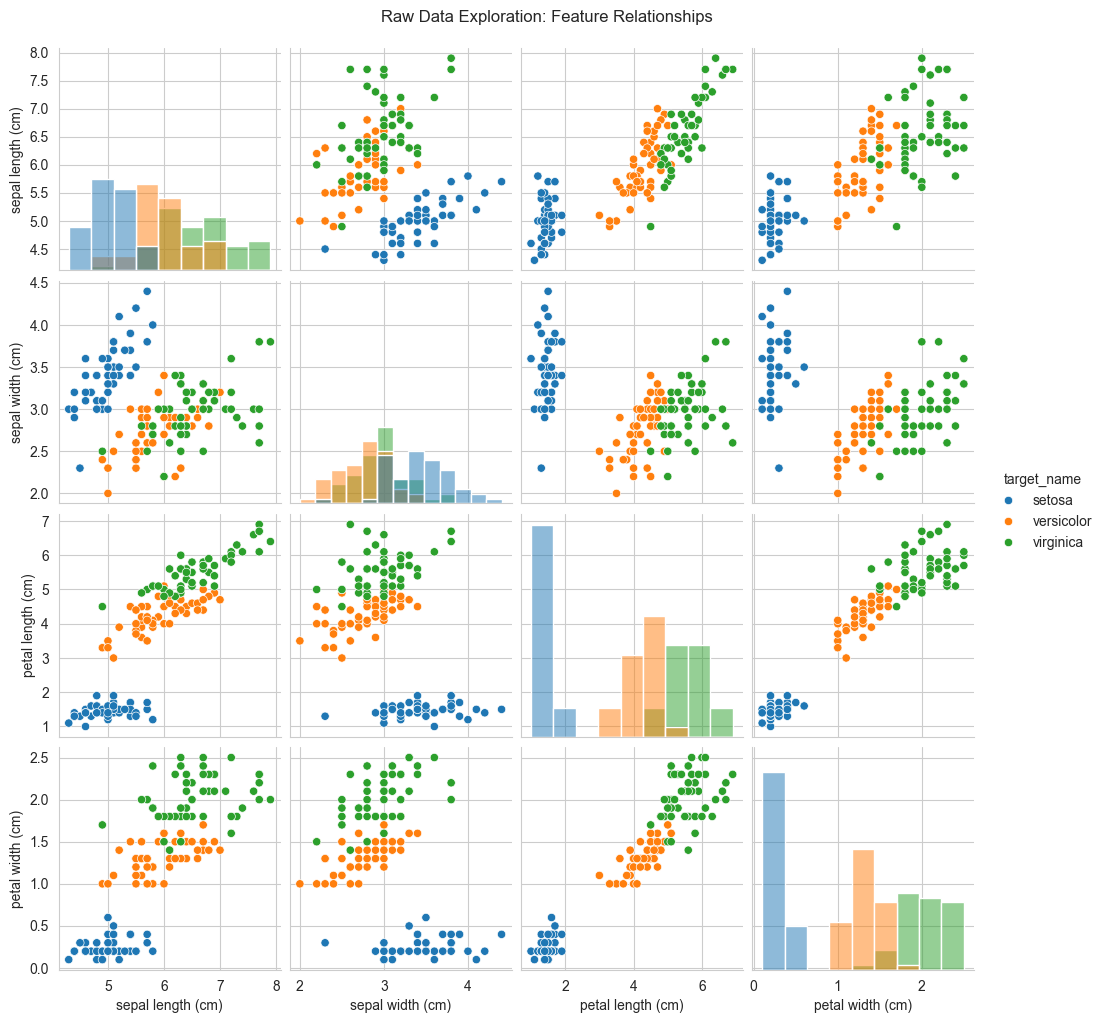

In [5]:
sns.pairplot(df, hue='target_name', vars=data.feature_names, diag_kind='hist')
plt.suptitle('Raw Data Exploration: Feature Relationships', y=1.02)
plt.show()

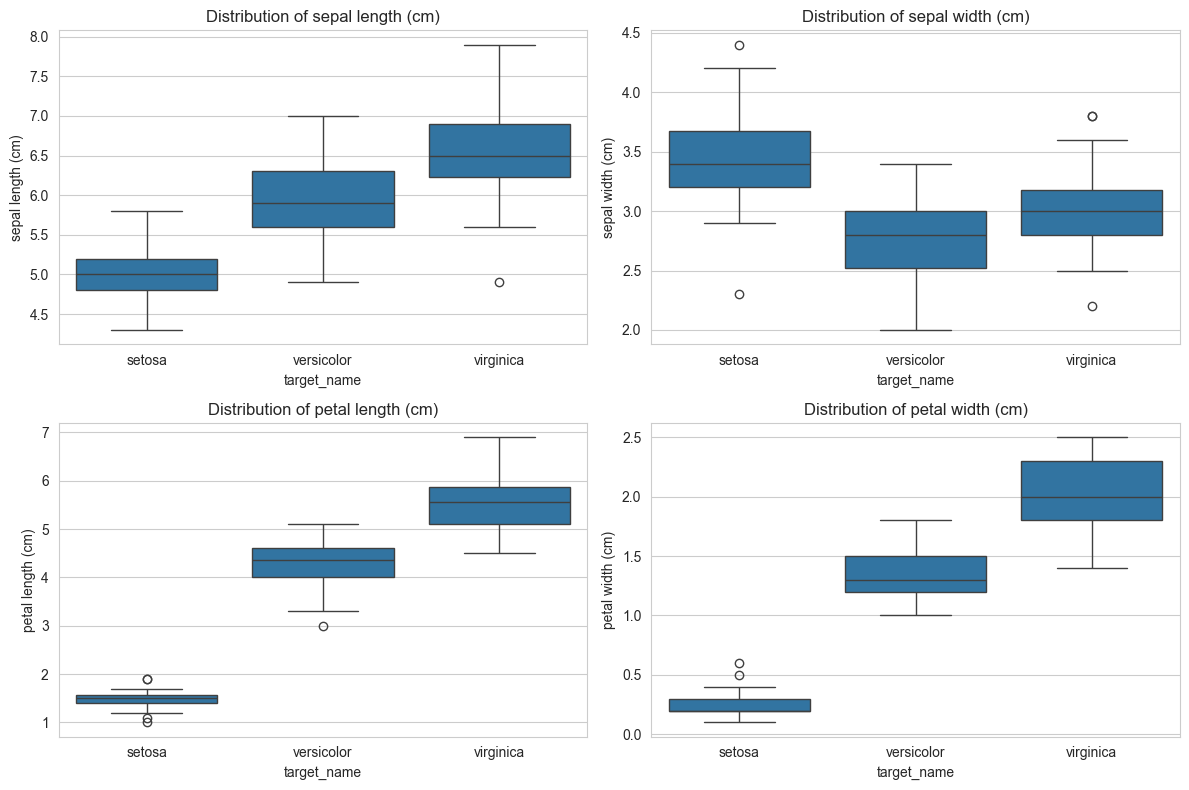

In [7]:
fig, axes = plt.subplots(2,2, figsize=(12, 8))
for i, feature in enumerate(data.feature_names):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='target_name', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()


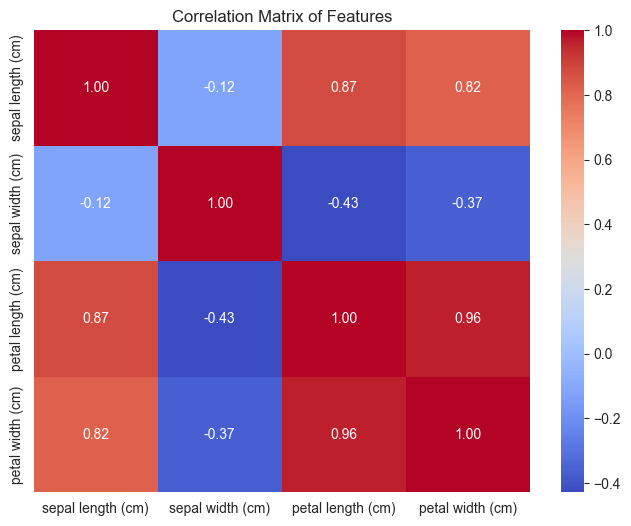

In [9]:
plt.figure(figsize=(8, 6))
correlation_matrix = df [data.feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [10]:
x = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print("\n Data Split complete. No standardScaler needed here!")

Training samples: 120
Testing samples: 30

 Data Split complete. No standardScaler needed here!


In [11]:
dt_model = DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")


Decision Tree trained successfully!


In [12]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Trained successfully!")


Random Forest Trained successfully!


In [13]:
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

In [15]:
print("="*50)
print("DECISION TREE PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

print("\n" + "="*50)
print("RANDOM FOREST PERFORMANCE")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))

DECISION TREE PERFORMANCE METRICS
Accuracy: 0.9667
F1-Score: 0.9666

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


RANDOM FOREST PERFORMANCE
Accuracy: 0.9667
F1-Score: 0.9666

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
plt.figure(figsize=(14, 8))
plot_tree(
    dt_model,
    feature_names=data.feature_names,
    class_names=data.target_names
    filled=True,
    rounded=True,
    fontsize=12,
    proportion=True
)

plt.title("Visualizing the Decision Tree (Depth=3)", fontsize=16)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2400810148.py, line 5)